# Модуль В. Тестирование разработанной модели

## Импортирование библиотек

## Автоматизированное тестирование

Для реализации `автоматизированного тестированния` своего решения, я буду использовать `unit-тесты`, а также структуру которая работает в существующем приложении

Все тесты реализованы в файле `test_reailzation.py`

```py
# импортирование библиотек
# импортирую класс с реализацией
from backend import Realization
# импортирую юнит тесты
import unittest
# для работы с видеокартой
import torch
# импортирую подготовленные текст
from texts import *

# -------------------------------------------------------------
# подготовка всех параметров
summarization_path = 'Module2/saved_model'                          # путь к модели суммаризации
similarity_path = 'Module2/doc2vec_e50_w2_mc1_dw0_dm1_.model'       # путь к модели сравнения
df_path = 'Module2/all_embs.pkl'                                    # путь к датафрейму с эмбеддингами
# девайс (CUDA или CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# создаем класс для тестов входных данных модели
class TestRealizationInput(unittest.TestCase):
    # проверка обработки путя к модели суммаризации
    def test_sum_path(self):
        # неправильный формат
        with self.assertRaises(TypeError):
            realizator = Realization(112, similarity_path, df_path, device)
        # путь не верный
        with self.assertRaises(FileNotFoundError):
            realizator = Realization('', similarity_path, df_path, device)

    # проверка обработки путя к модели сравнения
    def test_sim_path(self):
        # неправильный формат
        with self.assertRaises(TypeError):
            realizator = Realization(summarization_path, 52, df_path, device)
        # путь не верный
        with self.assertRaises(FileNotFoundError):
            realizator = Realization(summarization_path, '', df_path, device)

    # проверка обработки путя к датафрейму с эмбеддингами
    def test_df_path(self):
        # неправильный формат
        with self.assertRaises(TypeError):
            realizator = Realization(summarization_path, similarity_path, 52, device)
        # путь не верный
        with self.assertRaises(FileNotFoundError):
            realizator = Realization(summarization_path, similarity_path, '', device)

    # проверка девайса
    def test_device_input(self):
        # неправильный формат
        with self.assertRaises(TypeError):
            realizator = Realization(summarization_path, similarity_path, df_path, 42)

# создаем класс для тестов значений вывода модели
class TestRealizationOutput(unittest.TestCase):
    # проверка схожести статей №1 (схожие)
    def test_large_sim(self):
        # создаем объект с реализацией
        realizator = Realization(summarization_path, similarity_path, df_path, device)
        # получаем суммаризацию для обоих текстов
        summary1 = realizator.get_summary(TEXT1)
        summary2 = realizator.get_summary(TEXT2)
        # проверяем формат вывода суммаризации
        self.assertTrue(type(summary1) == str)
        self.assertTrue(type(summary2) == str)
        # получаем схожесть статей
        similarity = realizator.get_similarity(summary1, summary2)
        # проверяем формат вывода схожести
        self.assertTrue(type(similarity) == float)
        # проверяем вывод (схожесть должна быть больше 50%)
        self.assertTrue(similarity > 0.50)

    # проверка схожести статей №2 (разные)
    def test_small_sim(self):
        # создаем объект с реализацией
        realizator = Realization(summarization_path, similarity_path, df_path, device)
        # получаем суммаризацию для обоих текстов
        summary1 = realizator.get_summary(TEXT1)
        summary2 = realizator.get_summary(TEXT3)
        # проверяем формат вывода суммаризации
        self.assertTrue(type(summary1) == str)
        self.assertTrue(type(summary2) == str)
        # получаем схожесть статей
        similarity = realizator.get_similarity(summary1, summary2)
        # проверяем формат вывода схожести
        self.assertTrue(type(similarity) == float)
        # проверяем вывод (схожесть должна быть больше 50%)
        self.assertTrue(similarity < 0.50)

# запускаем тесты
if __name__ == "__main__":
    unittest.main()
```

Для запуска тестов, перейдите в файл `test_realization.py` и запустите его

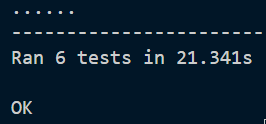

Все тесты прошли успешно, и реализационная часть кода устойчива к неправильным инпутам, а также показывает хорошие результаты в сравнении статей

## Модульное тестирование

В этой части модуля, будет реализовано `3` `тест кейса`, для проверки работы `API` и возможностей моделей работать с текстами на разные темы

### 1. **Программирование**

Первый тест кейс посвящен теме "`Программирование`", так как в исходных данных большинство статей - это технические `статьи про программирование на русском языке`

Следовательно, `модель` с бОльшей точностью сможет вывести `суммаризацию` этих статей, и `сравнить их сходство`

### 2. **Кошки и программирование**

Второй тест кейс на тему "`Кошки и программирование`". Благодаря разности этих тем, можно увидеть `умеет ли` `модель различать темы`

### 3. **Английский язык**

Третий тест кейс покажет способности модели работать на разных языках *(в данном случае, на `английском`)*. Из-за особенности `предобученной модели` которую я использую, технически она всё ещё способна работать на английском языке, и я хочу `протестировать` это